# Load SP500 stock data using Yahoo Finance

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import datetime
import yfinance as yf

In [2]:
# Optional: interactive DataFrame tables in Jupyter (requires: pip install itables)
# Old API `init_itables(bootstrap_mode=True)` was removed; use `init_notebook_mode`.
# connected=True loads DataTables from CDN (similar idea to bootstrap CDN).
from itables import init_notebook_mode

init_notebook_mode(all_interactive=True, connected=True)

In [3]:
from dotenv import load_dotenv
load_dotenv()

from pairs_eda import fetch_sp500_constituents_table, default_gemini_backend, ExaRunMode

exa_backend = default_gemini_backend()
sp500 = fetch_sp500_constituents_table(
    on_failure="exa",
    exa_backend=exa_backend,
    exa_mode=ExaRunMode.LIVE,
    verbose=True,
)

sp500_list = sp500["Symbol"].tolist()
print(f"{len(sp500_list)} symbols fetched")

[pairs_eda] Fetching https://en.wikipedia.org/wiki/List_of_S%26P_500_companies …
[pairs_eda] Extracting tables …
[pairs_eda] Done (503 rows from https://en.wikipedia.org/wiki/List_of_S%26P_500_companies).
503 symbols fetched


In [4]:
# ── Time Configuration ──
# Phase 1:  max daily history for regime-aware strategy design
# Phase 2a: 1h interval, 730 days — reassurance across recent market events
# Phase 2b: 5m interval, 60 days  — execution-level validation
# Each phase is a SEPARATE download with different intervals.

PHASE2A_DAYS = 730
PHASE2A_INTERVAL = "1h"
PHASE2B_DAYS = 60
PHASE2B_INTERVAL = "5m"
DOWNLOAD_START = "1990-01-01"          # go as far back as yfinance allows

# Tickers must have data on or before this date.
# 2000-01-01 captures dot-com bubble, GFC, COVID, and rate-hike regimes.
MIN_HISTORY_START = "2000-01-01"

end_time = datetime.datetime.today()
p2b_end   = end_time - pd.DateOffset(days=1)                        # yesterday
p2b_start = p2b_end  - pd.DateOffset(days=PHASE2B_DAYS - 1)         # 60 days inclusive
p2a_end   = p2b_start - pd.DateOffset(days=1)                       # day before Phase 2b
p2a_start = p2a_end  - pd.DateOffset(days=PHASE2A_DAYS - 1)         # 730 days inclusive
p1_end    = p2a_start - pd.DateOffset(days=1)                       # day before Phase 2a

print(f"Phase 1  download: {DOWNLOAD_START} → {p1_end.date()}")
print(f"Phase 1  filter:   tickers must have data by {MIN_HISTORY_START}")
print(f"Phase 2a window:   {p2a_start.date()} → {p2a_end.date()} ({PHASE2A_DAYS}d, {PHASE2A_INTERVAL})")
print(f"Phase 2b window:   {p2b_start.date()} → {p2b_end.date()} ({PHASE2B_DAYS}d, {PHASE2B_INTERVAL})")


Phase 1  download: 1990-01-01 → 2024-01-25
Phase 1  filter:   tickers must have data by 2000-01-01
Phase 2a window:   2024-01-26 → 2026-01-24 (730d, 1h)
Phase 2b window:   2026-01-25 → 2026-03-25 (60d, 5m)


In [5]:
from pairs_eda import download_with_retry

# ── Phase 1: Download daily OHLCV (maximum history) ──
# auto_adjust=False: preserves "Adj Close" column separately.
# Over 10-35 years, Adj Close differs significantly from Close
# (e.g. JPM adj/close ratio ≈ 0.32 at 1990 due to decades of splits/dividends).
# Pairs trading MUST use Adj Close so corporate actions don't create false spread signals.
sp500_daily_prices = download_with_retry(
    sp500_list,
    start=DOWNLOAD_START,
    end=p1_end,
    interval="1d",
    progress=True,
    threads=True,
    auto_adjust=False,
    max_retries=2,
    retry_delay=5.0,
)

# No per-ticker date filter — overlap is checked at the PAIR level
# by find_candidate_pairs(min_overlap_years, recent_years).
# This allows newer stocks (GOOGL, TSLA, META, etc.) to participate.

# ── Data availability summary ──
first_valid = pd.Series({col: sp500_daily_prices[col].first_valid_index() for col in sp500_daily_prices.columns})
print(f"\nPhase 1 data:")
print(f"  Tickers:       {sp500_daily_prices.shape[1]}")
print(f"  Trading days:  {sp500_daily_prices.shape[0]}")
print(f"  Earliest data: {first_valid.min().date()}")
print(f"  Median start:  {first_valid.median().date()}")
print(f"  p1_end:        {p1_end.date()}")


[pairs_eda] Downloading 503 tickers …


[******                13%                       ]  64 of 503 completed$SNDK: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-25 01:35:36.360951) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706164536")
[*******************   39%                       ]  194 of 503 completed$SOLV: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-25 01:35:36.360951) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706164536")
[**********************53%                       ]  269 of 503 completed$GEV: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-25 01:35:36.360951) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706164536")
[**********************84%***************        ]  422 of 503 completed$Q: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-25 01:35:36.360951) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706164536")
[****

[pairs_eda] Using 'Adj Close' — split/dividend adjustments detected.
[pairs_eda] Retry 1/2: 5 failed tickers → ['GEV', 'HOLX', 'Q', 'SNDK', 'SOLV']


$Q: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-25 01:35:36.360951) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706164536")
[                       0%                       ]$GEV: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-25 01:35:36.360951) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706164536")
[*******************   40%                       ]  2 of 5 completed$SOLV: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-25 01:35:36.360951) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706164536")
[**********************60%****                   ]  3 of 5 completed$SNDK: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-25 01:35:36.360951) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706164536")
[*********************100%***********************]  5 of 5 completed

4 Failed downloads:
['Q', 'GEV', 'SO

[pairs_eda] Retry 1: recovered ['HOLX']
[pairs_eda] Retry 1: still failing ['GEV', 'Q', 'SNDK', 'SOLV']
[pairs_eda] Retry 2/2: 4 failed tickers → ['GEV', 'Q', 'SNDK', 'SOLV']


/home/danielyouk/crypto-trading-rs/python/pairs_eda/yfinance_tools.py:103: UserWarning: [pairs_eda] 'Adj Close' and 'Close' are identical — no split/dividend adjustments found. This can happen with auto_adjust=True or short intraday windows. Using 'Close'.
  retry_panel = adj_close_or_close_panel(retry_dl, verbose=False)
$SOLV: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-25 01:35:36.360951) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706164536")
$SNDK: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-25 01:35:36.360951) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706164536")
[                       0%                       ]$GEV: possibly delisted; no price data found  (1d 1990-01-01 -> 2024-01-25 01:35:36.360951) (Yahoo error = "Data doesn't exist for startDate = 631170000, endDate = 1706164536")
[                       0%                       ]$Q: possibly delisted; no price data found  

[pairs_eda] Retry 2: still no data.
[pairs_eda] Dropping 4 tickers after all retries: ['GEV', 'Q', 'SNDK', 'SOLV']

Phase 1 data:
  Tickers:       499
  Trading days:  8581
  Earliest data: 1990-01-02
  Median start:  1991-10-24
  p1_end:        2024-01-25


In [ ]:
# ── Volatility Pre-Filter ─────────────────────────────────────────────────────
# Remove tickers that have experienced extreme single-day moves.
# Such stocks can temporarily break the pair relationship, producing spurious
# signals that are not recoverable within the z-score mean-reversion window.
#
# max_move_quantile=0.90 → exclude the top 10% most extreme movers.
# The threshold is computed from the actual distribution, so it adapts
# automatically across different market regimes (e.g. 2000 dot-com vs. 2015).
from pairs_eda import filter_volatile_tickers

sp500_daily_prices = filter_volatile_tickers(
    sp500_daily_prices,
    max_move_quantile=0.90,
)

# Deriving highly correlated stock combinations for pair trading

## Phase 1 / 2a / 2b

| Phase | Purpose | Interval | Period |
|-------|---------|----------|--------|
| **Phase 1** | Correlation, cointegration, strategy optimization, regime detection | Daily (1d) | Max history → p1_end |
| **Phase 2a** | Reassurance across recent market events (volatility, rate changes) | 1-hour (1h) | 730 days (p2a_start → p2a_end) |
| **Phase 2b** | Execution-level validation (slippage, spread mechanics) | 5-minute (5m) | 60 days (p2b_start → p2b_end) |


In [6]:
# ── Phase Timeline ──
#
#   1990                       p1_end  p2a_start       p2a_end  p2b_start    p2b_end
#   |======== P1 (daily) ======|       |==== P2a (1h) ===|      |== P2b (5m) ==|
#   DOWNLOAD_START              ↑       730 days                  60 days       yesterday
#                     pair overlap checked here (≥5yr + 3yr recency)
#
# Three SEPARATE downloads:
#   P1  = daily Adj Close  (26+ years, 4 major regime crises)
#   P2a = 1h Adj Close    (2 years, recent event coverage)
#   P2b = 5m Adj Close    (60 days, execution mechanics)

print(f"Phase 1:  {DOWNLOAD_START} → {p1_end.date()}  (all available daily data)")
print(f"Phase 2a: {p2a_start.date()} → {p2a_end.date()}  ({(p2a_end - p2a_start).days + 1} calendar days, {PHASE2A_INTERVAL})")
print(f"Phase 2b: {p2b_start.date()} → {p2b_end.date()}  ({(p2b_end - p2b_start).days + 1} calendar days, {PHASE2B_INTERVAL})")


Phase 1:  1990-01-01 → 2024-01-25  (all available daily data)
Phase 2a: 2024-01-26 → 2026-01-24  (730 calendar days, 1h)
Phase 2b: 2026-01-25 → 2026-03-25  (60 calendar days, 5m)


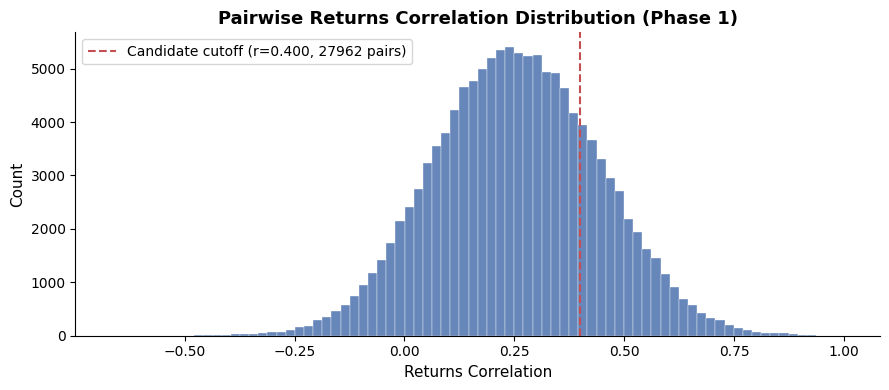

In [7]:
import matplotlib.pyplot as plt
from pairs_eda import compute_pairwise_return_correlations, plot_correlation_histogram

all_corr = compute_pairwise_return_correlations(sp500_daily_prices, end=p1_end)
fig, ax = plot_correlation_histogram(all_corr, cutoff=0.40)
plt.show()


In [8]:
from ipywidgets import interact, Output, widgets
from plotly import graph_objs as go
from IPython.display import display, clear_output
from pairs_eda import find_candidate_pairs

# Select candidate pairs: r in [0.40, 0.85], dual condition (full + 3yr recent).
# Hover over find_candidate_pairs for the full filtering logic.
pair_correlations = find_candidate_pairs(sp500_daily_prices, end=p1_end, min_correlation=0.40, max_correlation=0.85)
high_correlated_pairs = list(pair_correlations.keys())
print(f"{len(high_correlated_pairs)} candidate pairs")

# Dropdown: top 100 pairs by correlation, pick one to see dual-axis price chart.
top_pairs = list(pair_correlations.keys())[:100]

pair_dropdown = widgets.Dropdown(
    options=[(f"{a} / {b}  (r={pair_correlations[(a,b)]:.4f})", (a, b)) for a, b in top_pairs],
    description="Pair:",
)

plot_output = Output()
display(plot_output)

def update_graph(selected_pair):
    with plot_output:
        clear_output(wait=True)
        a, b = selected_pair
        pair_data = sp500_daily_prices[[a, b]].dropna()
        # Normalize: both start at 1.0 from their first overlapping date
        normalized = pair_data / pair_data.iloc[0]
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=normalized.index, y=normalized[a], name=a))
        fig.add_trace(go.Scatter(x=normalized.index, y=normalized[b], name=b))
        fig.update_layout(
            yaxis=dict(title=dict(text="Price (normalized to 1.0)")),
            title=f"{a} vs {b} — Normalized Price (r={pair_correlations[(a,b)]:.4f})",
            xaxis_title="Date",
        )
        fig.show()

interact(update_graph, selected_pair=pair_dropdown);

15902 candidate pairs


Output()

interactive(children=(Dropdown(description='Pair:', options=(('CFG / USB  (r=0.8349)', ('CFG', 'USB')), ('BAC …

# Pair Trading Backtesting (Functional)

### Functional Pipeline

Each step is an independent, testable function. Data flows explicitly through arguments and return values — no hidden state.

```
compute_zscore  →  compute_signals  →  summarize_signals  →  calculate_margin
                                                                     ↓
backtest_pair (chains all four)                              {margin, trade_log}
grid_search_pair (parameter sweep)
```

## Step-by-Step Demo: One Pair Backtest

Using the **top-ranked pair from ** as a worked example,
this section walks through each stage of the backtest pipeline.  
Run cells **in order** and inspect each intermediate result at every step.

---

### Pipeline Flow



---

### Parameters

| Parameter | Value | Meaning |
|---|---|---|
|  | 10 | z-score rolling window (trading days) |
|  | 2.0 | entry threshold — signal fires when \|z\| ≥ 2.0 |
|  | 3,000 | initial margin / collateral (USD) |
|  | 0.25 | margin ratio — 0.25 = **4× leverage** (buying power = margin ÷ 0.25) |

> **Bankruptcy threshold**: margin < $2 → cannot cover minimum commission ($1/leg)
> → simulation stops and  is recorded

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
# run_pair_pipeline : runs all 4 steps in sequence; stores every intermediate in PairPipelineState
#   call .to_backtest_result() to extract compact dict {pair, window, zscore_threshold, margin}
# grid_search_pair  : runs run_pair_pipeline over the full parameter grid
import numpy as np
from pairs_eda.backtesting import (
    grid_search_pair,
    run_pair_pipeline,
)

In [ ]:
from typing import cast

import pandas as pd

from pairs_eda.display import (
    print_margin_summary,
    print_signal_distribution,
    print_signal_groups,
    print_zscore_summary,
)

# ── 1. Choose the pair ────────────────────────────────────────────────────────
# Pick the top-ranked pair that survived the volatility filter and correlation filter.
# Using the first entry from high_correlated_pairs ensures the demo always runs
# on a pair that is actually present in sp500_daily_prices.
demo_pair = next(iter(high_correlated_pairs))
print(f"Demo pair: {demo_pair[0]} / {demo_pair[1]}")

# Drop NaN rows from each Adj Close series; keep only the date range covered by both tickers.
# → Removes dates where one ticker listed later or has missing data, aligning both indexes.
prices_a = sp500_daily_prices[demo_pair[0]].dropna()
prices_b = sp500_daily_prices[demo_pair[1]].dropna()
common_idx = prices_a.index.intersection(prices_b.index)
# cast: single-column DataFrame access returns Series|DataFrame to Pyright; narrow explicitly.
prices_a = cast(pd.Series, prices_a.loc[common_idx])
prices_b = cast(pd.Series, prices_b.loc[common_idx])

# ── 2. Parameters ─────────────────────────────────────────────────────────────
WINDOW       = 10    # z-score rolling window (trading days)
THRESHOLD    = 2.0   # signal threshold  — entry when |z| >= 2.0
MARGIN_INIT  = 3000  # initial margin (USD)
MARGIN_RATIO = 0.25  # margin ratio  → buying power = $3000 / 0.25 = $12,000
STOP_LOSS    = 0.05  # exit early if unrealized loss exceeds 5% of buying power

# ── 3. Run the pipeline ───────────────────────────────────────────────────────
# run_pair_pipeline executes all 4 steps in order and stores every intermediate artifact.
#
#   compute_zscore -> compute_signals -> summarize_signals -> calculate_margin
#
# fractional=True  : equal dollar allocation per leg (fractional shares allowed)
# fractional=False : integer shares via math.floor (closer to a real brokerage account)
pipeline_state = run_pair_pipeline(
    prices_a=prices_a,
    prices_b=prices_b,
    window=WINDOW,
    zscore_threshold=THRESHOLD,
    margin_init=MARGIN_INIT,
    margin_ratio=MARGIN_RATIO,
    pair=demo_pair,
    fractional=True,
    stop_loss_pct=STOP_LOSS,
)

# ── 4. Unpack intermediates ───────────────────────────────────────────────────
# pair_stats    : date-indexed DataFrame — ratio / ma / msd / zscore / signal
#                 inspect to verify how z-score and signal were computed for each date
# signal_summary: one-row-per-period DataFrame — date ranges, prices, pnl, commission, ...
#                 pnl/commission columns are filled only for active trades (signal != 0)
pair_stats     = pipeline_state.pair_stats
signal_summary = pipeline_state.signal_summary

---

### Step 1 — Z-Score: How Far Is the Spread From Normal?

Inspect the `pair_stats` DataFrame to see how each column is derived.

| Column | Meaning |
|---|---|
| `ratio` | log(price_A / price_B) — log price ratio of the two stocks |
| `ma` | rolling mean of `ratio` over `WINDOW` days (shifted 1 day to avoid lookahead) |
| `msd` | rolling std of `ratio` over `WINDOW` days (same shift) |
| `zscore` | (ratio − ma) / msd — how many standard deviations the spread is from its mean |
| `signal` | directional signal derived from zscore (-1 / 0 / +1) |

> **Why the 1-day shift?** Using today's MA/MSD to generate today's signal introduces lookahead bias.  
> MA and MSD must be computed from data up to (and including) the prior day.

In [ ]:
# Browse the pair_stats DataFrame directly — verify z-score and signal values by date.
pair_stats

In [ ]:
# Last 8 rows summary + full z-score range
print_zscore_summary(pair_stats)

---

### Step 2 — Signals: When Do We Enter and Exit?

- **signal = +1**: z-score ≥ +THRESHOLD → A overvalued → **long B / short A**
- **signal = -1**: z-score ≤ −THRESHOLD → A undervalued → **long A / short B**
- **signal =  0**: neutral — no position

> The **moment the signal changes is the entry/exit trigger**.  
> 0 → ±1: open a new position.  ±1 → 0: close the position.

In [ ]:
# Count occurrences of each signal value — check that long, short, and neutral are roughly balanced.
print_signal_distribution(pair_stats, threshold=THRESHOLD)

---

### Step 3 — Signal Grouping: Date Range for Each Trade

`signal_summary` collapses **every contiguous run of the same signal into a single row**.

| Column | Meaning |
|---|---|
| `signal` | direction for this period (+1 / -1 / 0) |
| `time_start` | first day of the period → **entry price** |
| `time_end` | last day of the period → **exit price** |
| `stock1_units / stock2_units` | shares held per leg (filled for active trades only) |
| `pnl` | **gross P&L** from price movement (before commission) |
| `commission` | IB fee — $0.005/share, max 1% of trade value + SEC + FINRA |
| `margin_after` | margin remaining after this trade |

> Rows where `pnl` / `commission` are **NaN = neutral period** (no trade executed)

In [ ]:
# Browse signal_summary directly — scroll through each trade's dates, prices, and P&L.
# To see active trades only: signal_summary[signal_summary["signal"] != 0]
signal_summary

In [ ]:
# Print the first 10 periods — signal direction, date range, entry/exit prices
print_signal_groups(signal_summary)

---

### Step 4 — Margin & P&L: Did the Strategy Make Money?

Margin is updated after every trade:

```
margin_after = margin_before + pnl - commission
```

- **`pnl` (gross)**: profit from price movement — includes 3-pip slippage, excludes commission
- **`commission`**: IB fee — $0.005/share, min $1, max 1% of trade value
  + SEC Transaction Fee + FINRA TAF (sell leg only)
- **`Liquidated` label**: margin < $2 → simulation stops. Subsequent rows have NaN trade columns.

In [ ]:
# Step 4 summary — initial/final margin, total P&L, trade count, and first 5 trades in detail
print_margin_summary(
    signal_summary,
    MARGIN_INIT,
    pipeline_state.margin_final,
    pipeline_state.liquidation_date,
)

---

## Design Note: Stop-Loss and Cooldown Period

### Why pairs trading still needs a stop-loss

Pairs trading is market-neutral in theory — gains on one leg offset losses on the other.
However, **structural breaks** do occur in practice:

| Cause | Example | Effect |
|---|---|---|
| Sector rotation | Tech vs. Financials decouple in a rate cycle | Spread diverges permanently |
| M&A announcement | Target stock +40% overnight | Ratio jumps; mean-reversion unlikely |
| Earnings shock | One ticker misses badly; other beats | Correlation breaks for months |
| Index removal | Ticker dropped from S&P 500 | Buying pressure disappears |

Without a stop-loss, the position is held hoping the spread reverts — but after a structural
break it never does, and the account bleeds continuously.

---

### Stop-loss rule

```
stop_loss_pct = 0.05   (5% of buying_power)

buying_power = current_margin / margin_ratio
                e.g.  $3000 / 0.25 = $12,000

5% threshold  = 0.05 × $12,000 = $600

Each day while a trade is open:
    unrealized_P&L = (price_change_long_leg) - (price_change_short_leg)
                    = (p_a_now - p_a_entry) × units_a
                    - (p_b_now - p_b_entry) × units_b

    if unrealized_P&L < -$600:
        → EXIT immediately at today's close
        → mark trade as stopped_out = True
        → record stop_date
```

> **Note**: The stop-loss check uses raw (no-slippage) prices for the daily
> monitoring.  Slippage is still applied at the actual exit.

---

### Cooldown period after a stop-loss

After exit, the z-score history is **contaminated** — the rolling window still
contains bars from the abnormal event.  Any signal generated during this window
is based on a distorted mean and std, so re-entry would be unreliable.

```
cooldown_days = window   (same as the rolling z-score window)

Timeline:

  T+0  Trade opens
  T+2  Stock A crashes → stop-loss triggered, exit at T+2 close
  T+3  ┐
  T+4  │  cooldown period — skip ALL signals for `window` bars
  ...  │  (z-score still contains T+2 crash in its rolling window)
  T+W  ┘  cooldown ends
  T+W+1  Normal signal generation resumes
```

The pair remains a **candidate** after the cooldown — it is not permanently excluded.
If the structural break was temporary (e.g. earnings, not M&A), the pair can trade again.

---

### What you can inspect in `signal_summary`

After running `run_pair_pipeline(stop_loss_pct=0.05)`, the `signal_summary` DataFrame
has two additional columns for active trades:

| Column | Type | Meaning |
|---|---|---|
| `stopped_out` | bool | True if the trade was cut by stop-loss |
| `stop_date` | str\|None | Date of stop-loss exit (`'YYYY-MM-DD'`); None otherwise |

And `PairPipelineState.n_stops` gives the total count of stop-loss events for the pair.

```python
# Filter for stopped-out trades only:
signal_summary[signal_summary['stopped_out'] == True]

# Count stop-loss events:
pipeline_state.n_stops
```

---

### Live trading notes

When deploying to a live account, the stop-loss logic maps to these IB TWS API calls:

```
SIMULATION (this backtest)          LIVE TRADING (IB TWS API)
─────────────────────────────────   ──────────────────────────────────────────
daily close price check             real-time tick subscription (reqMktData)
unrealized_P&L < -threshold         portfolio.unrealizedPNL < -threshold  
exit at today's close               placeOrder(MarketOrder, action='SELL'/'BUY')
skip next window bars               set cooldown_until timestamp in state dict
                                    ignore signals until datetime.now() > cooldown_until
```

> **Risk**: In live trading, a gap-down open can breach the stop level before
> the order fills (slippage > 3 pips assumed here).  Consider a slightly tighter
> threshold (e.g. 4%) in production to leave room for execution slippage.


## Parallel Processing Implementation by List Comprehension and Joblib

### List Comprehension Application

In [ ]:
def trading_summary_wt_parameters(prices_a, prices_b, pair, margin_init, margin_ratio):
    results = grid_search_pair(
        prices_a, prices_b,
        windows=range(3, 30, 1),
        zscore_thresholds=np.linspace(2.0, 4.0, 21),
        margin_init=margin_init,
        margin_ratio=margin_ratio,
        pair=pair,
        fractional=True,
    )
    return pd.DataFrame(results)

In [ ]:
# sp500_daily_prices was downloaded with end=p1_end — it already IS the Phase 1 data.
# No separate backtesting slice needed.
print(f"Backtesting data: {sp500_daily_prices.shape[1]} tickers, {sp500_daily_prices.shape[0]} days")

### Joblib Application for Parallel Processing

In [ ]:
from joblib import Parallel, delayed

In [ ]:
import os

num_cores = os.cpu_count()
print(num_cores)

In [ ]:
# Pre-extract pair columns: each worker receives only 2 Series, not the full ~500-column DataFrame.
pairs_trading_summary = Parallel(n_jobs=num_cores)(
    delayed(trading_summary_wt_parameters)(
        prices_a=sp500_daily_prices[pair[0]].dropna(),
        prices_b=sp500_daily_prices[pair[1]].dropna(),
        pair=pair,
        margin_init=3000,
        margin_ratio=0.25,
    )
    for pair in high_correlated_pairs
)

In [ ]:
pairs_trading_summary_df = pd.concat(pairs_trading_summary, ignore_index=True)

In [ ]:
if not os.path.exists("../data"):
    os.makedirs("../data")

pairs_trading_summary_df.to_pickle("../data/pairs_trading_summary_df.pkl")

# Deriving Optimal Parameters for PairsTrading through Statistical Methods

In [ ]:
top_margin_result = pairs_trading_summary_df.groupby("pair").head(20)
pairs_trading_top20_summary = (
    top_margin_result
    .groupby("pair")
    .agg(
        mean_window=('window', 'mean'),
        median_window=('window', 'median'),
        std_window=('window', 'std'),
        mean_zscore_threshold=('zscore_threshold', 'mean'),
        median_zscore_threshold=('zscore_threshold', 'median'),
        std_zscore_threshold=('zscore_threshold', 'std'),
        mean_margin=('margin', 'mean'),
        median_margin=('margin', 'median'),
        std_margin=('margin', 'std')
    )
    .sort_values(by="mean_margin", ascending=False)
    .reset_index(inplace=False)
)

pairs_trading_top20_summary["dist_window"] = pairs_trading_top20_summary["std_window"] / pairs_trading_top20_summary["mean_window"]
pairs_trading_top20_summary["dist_zscore_threshold"] = pairs_trading_top20_summary["std_zscore_threshold"] / pairs_trading_top20_summary["mean_zscore_threshold"]
pairs_trading_top20_summary["dist_margin"] = pairs_trading_top20_summary["std_margin"] / pairs_trading_top20_summary["mean_margin"]



In [ ]:
pairs_trading_top20_summary # If the distribution is too large, it means that the volatility is high, making it difficult to approach the data statistically. Conversely, if the distribution is too small, the optimal situation is concentrated at one point, so even a slight volatility in actual investment will deviate from the optimal situation. Therefore, when deciding on an investment portfolio in the future, we will choose a pair with a moderate distribution.

# Verifying (Reassurance) Pair Trading Strategy: OOP Part 2

## Phase 2a & 2b: Intraday reassurance

- **Phase 2a** (1h, 730 days): Does the strategy hold across recent market events?
- **Phase 2b** (5m, 60 days): Does it work at execution-level granularity?


In [ ]:
p2_tickers = sorted({t for pair in high_correlated_pairs for t in pair})
print(f"{len(p2_tickers)} unique tickers from {len(high_correlated_pairs)} pairs")


In [ ]:
# ── Phase 2a: Download 1-hour OHLCV (730 days) ──
# Validates strategy across recent market events (volatility spikes, rate changes).
# 1h interval allows up to 730 days of history from yfinance.
sp500_hourly_prices = download_with_retry(
    p2_tickers,
    start=p2a_start,
    end=p2a_end,
    interval=PHASE2A_INTERVAL,
    auto_adjust=False,
    max_retries=2,
    retry_delay=5.0,
)

print(f"Phase 2a data ({PHASE2A_INTERVAL}):")
print(f"  Tickers: {sp500_hourly_prices.shape[1]}")
print(f"  Bars:    {sp500_hourly_prices.shape[0]}")
print(f"  Range:   {sp500_hourly_prices.index[0]} → {sp500_hourly_prices.index[-1]}")

# ── Phase 2b: Download 5-minute OHLCV (60 days) ──
# Execution-level validation: slippage, bid-ask spread, intraday mechanics.
# 5m is the finest interval yfinance supports for ~60 days.
sp500_5m_prices = download_with_retry(
    p2_tickers,
    start=p2b_start,
    end=p2b_end,
    interval=PHASE2B_INTERVAL,
    auto_adjust=False,
    max_retries=2,
    retry_delay=5.0,
)

print(f"\nPhase 2b data ({PHASE2B_INTERVAL}):")
print(f"  Tickers: {sp500_5m_prices.shape[1]}")
print(f"  Bars:    {sp500_5m_prices.shape[0]}")
print(f"  Range:   {sp500_5m_prices.index[0]} → {sp500_5m_prices.index[-1]}")


## Intraday Backtest — Daily MA/MSD + Intraday Z-Score

In [ ]:
from pairs_eda.backtesting import backtest_pair_intraday

## List Comprehension Application - Return Calculation for Optimal Parameters

In [ ]:
def trading_summary_wt_opt_params(pair, prices_a_daily, prices_b_daily,
                                   prices_a_intraday, prices_b_intraday,
                                   margin_init, margin_ratio, df_opt_paras):
    row = df_opt_paras[df_opt_paras["pair"] == pair]
    window = int(round(row["mean_window"].values[0], 0))
    zscore_threshold = row["mean_zscore_threshold"].values[0]

    return backtest_pair_intraday(
        prices_a_intraday=prices_a_intraday,
        prices_b_intraday=prices_b_intraday,
        prices_a_daily=prices_a_daily,
        prices_b_daily=prices_b_daily,
        window=window,
        zscore_threshold=zscore_threshold,
        margin_init=margin_init,
        margin_ratio=margin_ratio,
        pair=pair,
        fractional=True,
    )

In [ ]:
# Pre-extract pair columns for each intraday backtest — avoids full DataFrame copies.
intraday_trading_summary_ls = [
    trading_summary_wt_opt_params(
        pair=pair,
        prices_a_daily=sp500_daily_prices[pair[0]].dropna(),
        prices_b_daily=sp500_daily_prices[pair[1]].dropna(),
        prices_a_intraday=sp500_5m_prices[pair[0]].dropna(),
        prices_b_intraday=sp500_5m_prices[pair[1]].dropna(),
        margin_init=3000,
        margin_ratio=0.25,
        df_opt_paras=pairs_trading_top20_summary,
    )
    for pair in high_correlated_pairs
]

In [ ]:
intraday_trading_summary_df = pd.DataFrame(intraday_trading_summary_ls).rename(columns={"margin": "intraday_margin"})

In [ ]:
intraday_trading_summary_df.intraday_margin.mean()

## Expected Return by Implementing Machine Learning

In [ ]:
# merge two dataframes
trading_summary_df = pd.merge(
    pairs_trading_top20_summary, # backtesting with daily interval
    intraday_trading_summary_df, # reassurance with high frequency (Intraday)
    on = "pair", suffixes = ("_1d", "_5m"))

In [ ]:
#! pip install -U scikit-learn

In [ ]:
trading_summary_df = trading_summary_df.dropna()

In [ ]:
# linear regression model with sklearn for x = mean_margin, y = margin
from sklearn.linear_model import LinearRegression

X = trading_summary_df[["mean_margin"]]
y = trading_summary_df["intraday_margin"]
lm = LinearRegression()
lm.fit(X, y)
trading_summary_df["predicted_margin"] = lm.predict(X)


In [ ]:
import plotly.graph_objects as go
trading_summary_df["dist_window"] = trading_summary_df["dist_window"].round(2)
trading_summary_df["dist_zscore_threshold"] = trading_summary_df["dist_zscore_threshold"].round(2)
trading_summary_df["dist_margin"] = trading_summary_df["dist_margin"].round(2)
trading_summary_df["mean_margin"] = trading_summary_df["mean_margin"].round(2)
trading_summary_df["intraday_margin"] = trading_summary_df["intraday_margin"].round(2)

# Create a scatter plot
fig = go.Figure()

# Add a scatter plot
fig.add_trace(go.Scatter(
    x=trading_summary_df["mean_margin"],
    y=trading_summary_df["intraday_margin"],
    mode='markers',
    name='Data',
    text=trading_summary_df["pair"],  # add tooltips
    hovertemplate = '<i>Pair</i>: %{text}<br><b>X</b>: %{x}<br><b>Y</b>: %{y}<br>' +
                    '<i>dist_window</i>: %{customdata[0]}<br><i>dist_zscore_threshold</i>: %{customdata[1]}<br><i>dist_margin</i>: %{customdata[2]}<extra></extra>',
    customdata=trading_summary_df[["dist_window", "dist_zscore_threshold", "dist_margin"]].values
))

# Add a trend line
fig.add_trace(go.Scatter(
    x=trading_summary_df["mean_margin"],
    y=trading_summary_df["predicted_margin"],
    mode='lines',
    name='Trend Line',
    line=dict(color='red')
))

# Set labels
fig.update_layout(
    xaxis_title="margin_backtesting",
    yaxis_title="margin_reassurance",
    title="Scatter Plot with Trend Line"
)

fig.show()

## Define the final Investment Portfolio

In [ ]:
# plot three histograms for window_dist, zscore_threshold_dist, and margin_dist with three subplots
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize = (20, 5))

ax[0].hist(trading_summary_df["dist_window"], bins = 50, edgecolor = "black")
ax[0].set_title("dist_window")

ax[1].hist(trading_summary_df["dist_zscore_threshold"], bins = 50, edgecolor = "black")
ax[1].set_title("dist_zscore_threshold")

ax[2].hist(trading_summary_df["dist_margin"], bins = 50, edgecolor = "black")
ax[2].set_title("dist_margin")

plt.show()


In [ ]:
trading_summary_df["diff_margin"] = abs(trading_summary_df["intraday_margin"] - trading_summary_df["predicted_margin"])

In [ ]:
trading_summary_df.to_pickle("../data/trading_summary_df.pkl")

In [ ]:
df_sel = trading_summary_df[(0.2 <= trading_summary_df.dist_window) & (trading_summary_df.dist_window <= 0.3) 
                            & (trading_summary_df.intraday_margin >= 3050) & 
                            (trading_summary_df.diff_margin <= 50)].sort_values(by="intraday_margin", ascending=False).set_index("pair")

In [ ]:
df_sel

In [ ]:
def keep_first_occurrence(origin_list):
    # Create a set to keep track of seen stock symbols
    seen = set()
    # Create a result list to keep the non-duplicated pairs
    result = []
    # First, add all the unique pairs from the primary_list to the result
    # If a stock symbol has already been seen, it is a duplicate and will not be added
    for pair in origin_list:
        if pair[0] not in seen and pair[1] not in seen:
            seen.update(pair)
            result.append(pair)
    return seen, result

pairs_set, pairs_list = keep_first_occurrence(df_sel.index)
df_sel = df_sel[df_sel.index.isin(pairs_list)]

In [ ]:
df_sel

In [ ]:
print(df_sel.intraday_margin.mean(), df_sel.predicted_margin.mean())

In [ ]:
# save df_sel to a pickle file
df_sel.to_pickle("../data/df_sel.pkl")